### Task 1: Dataset Exploration

In [3]:
# Import libraries
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Load Fashion-MNIST dataset
(X_train, Y_train), (X_test, Y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Dataset Dimensions
print("X_train dimensions: ", X_train.shape)
print("Y_train dimensions: ", Y_train.shape)
print("X_test dimensions: ", X_test.shape)
print("Y_test dimensions: ", Y_test.shape)

X_train dimensions:  (60000, 28, 28)
Y_train dimensions:  (60000,)
X_test dimensions:  (10000, 28, 28)
Y_test dimensions:  (10000,)


In [6]:
# Class names
class_names = [
    "T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

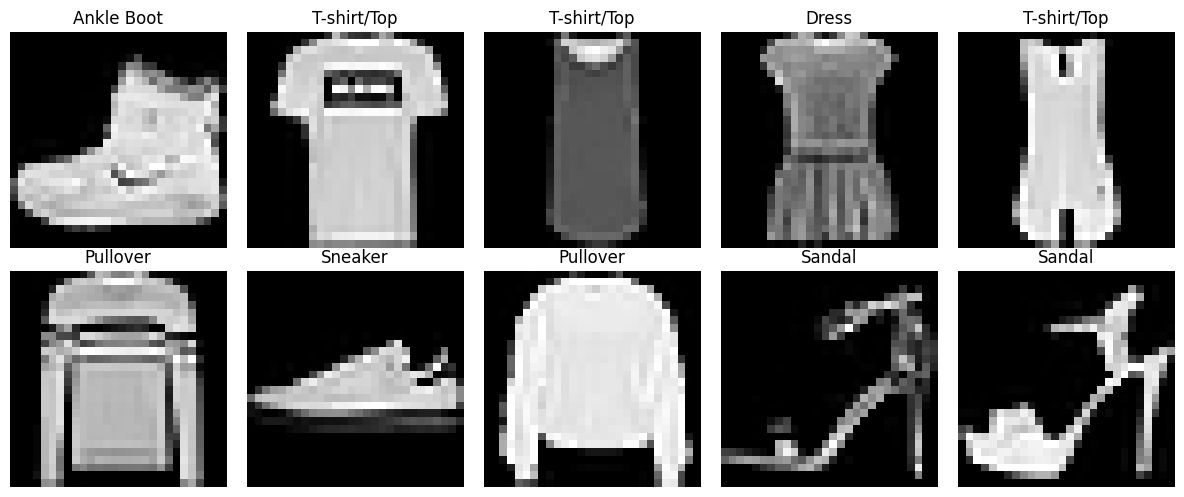

In [7]:
# Display 10 images

plt.figure(figsize=(12,5))

for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train[i], cmap = 'grey')
  plt.title(class_names[Y_train[i]])
  plt.axis("off")

plt.tight_layout()
plt.savefig(fname = "sample_images.eps", dpi = 600, format = "eps")
plt.show()

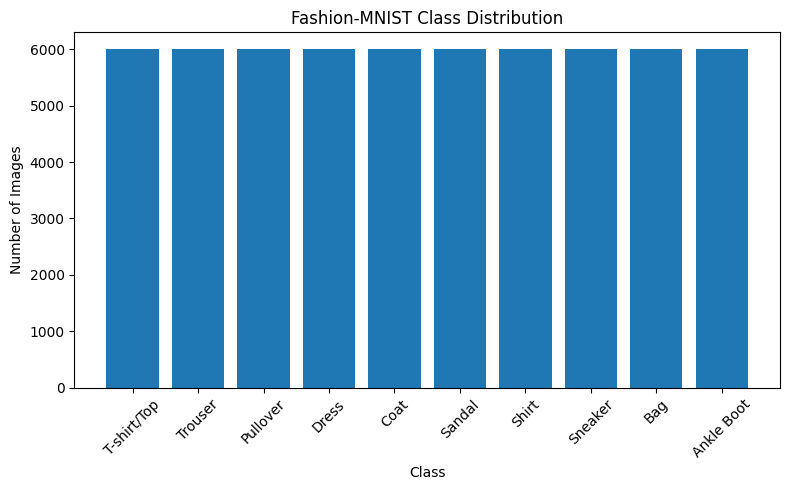

In [8]:
# Plot class distributions

unique, counts = np.unique(Y_train, return_counts = True)

plt.figure(figsize = (8, 5))
plt.bar(class_names, counts)
plt.title("Fashion-MNIST Class Distribution")
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.savefig(fname = "class_distribution.eps", dpi = 600, format = "eps")
plt.show()

### Task 2: Data Preprocessing

In [9]:
# Shape before preprocessing
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)

X_train Shape:  (60000, 28, 28)
X_test Shape:  (10000, 28, 28)


In [10]:
# Flattening
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [11]:
# Normalizing
X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [12]:
# Shape after preprocessing
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)

X_train Shape:  (60000, 784)
X_test Shape:  (10000, 784)


In [13]:
# Verify normalization
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Task 3: Model Construction

In [14]:
model = keras.Sequential([
    keras.layers.Input(shape = (784,)),
    keras.layers.Dense(128, activation = "relu"),
    keras.layers.Dense(64, activation = "relu"),
    keras.layers.Dense(10, activation = "softmax")
])

I0000 00:00:1784727699.465247      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784727699.468511      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Task 4: Model Training

In [16]:
from tensorflow.keras.utils import to_categorical

In [17]:
# Convert integer labels to one-hot vectors
y_train = to_categorical(Y_train, num_classes=10)
y_test = to_categorical(Y_test, num_classes=10)

In [18]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
  53/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4843 - loss: 1.5045

I0000 00:00:1784727705.973001     144 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8226 - loss: 0.5026 - val_accuracy: 0.8453 - val_loss: 0.4334
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8617 - loss: 0.3774 - val_accuracy: 0.8672 - val_loss: 0.3716
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8751 - loss: 0.3385 - val_accuracy: 0.8695 - val_loss: 0.3732
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8820 - loss: 0.3167 - val_accuracy: 0.8797 - val_loss: 0.3357
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8901 - loss: 0.2951 - val_accuracy: 0.8788 - val_loss: 0.3337
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8950 - loss: 0.2838 - val_accuracy: 0.8756 - val_loss: 0.3470
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8979 - loss: 0.2695 - val_accuracy: 0.8766 - val_loss: 0.3503
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9033 - loss: 0.2580 - val_accurac

#### Training Accuracy vs Epoch

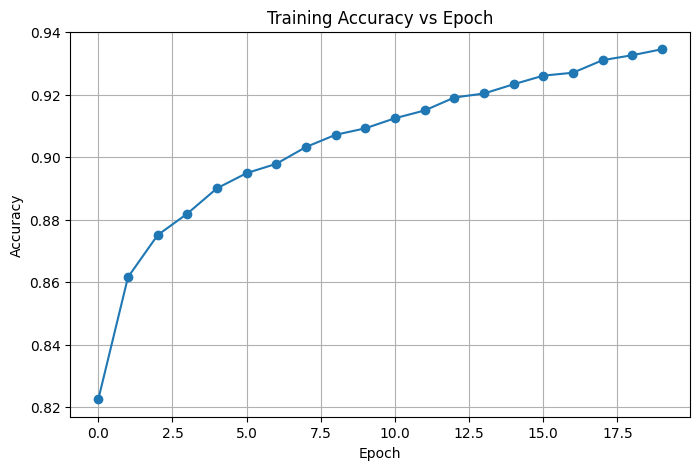

In [20]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], marker="o")
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

#### Validation Accuracy vs Epoch

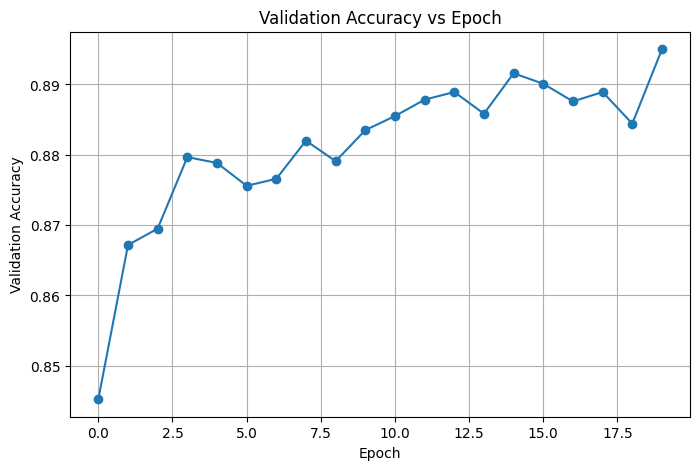

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history.history["val_accuracy"], marker="o")
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.show()

#### Training Loss vs Epoch

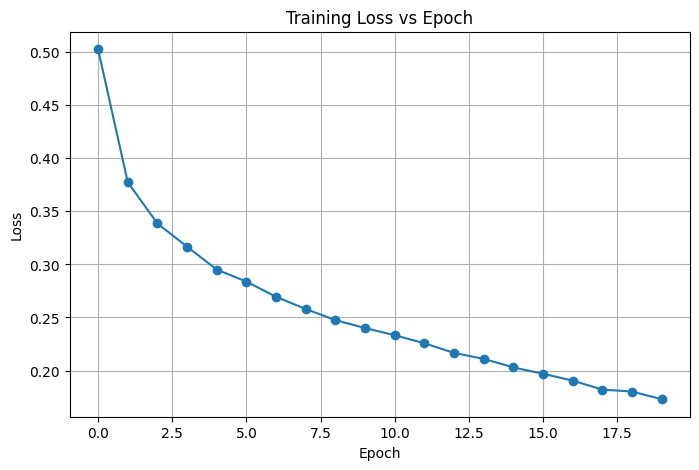

In [22]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], marker="o")
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

#### Validation Loss vs Epoch



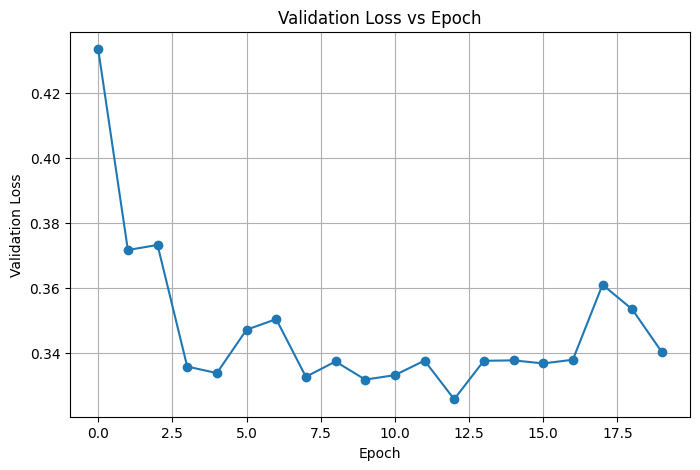

In [23]:
plt.figure(figsize=(8,5))
plt.plot(history.history["val_loss"], marker="o")
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(True)
plt.show()

### Task 5: Model Evaluation

In [24]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [25]:
# Predict probabilities
y_pred_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [26]:
# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)

In [27]:
# Convert one-hot encoded labels back to integer labels
y_true = np.argmax(y_test, axis=1)

In [28]:
# Compute evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

In [29]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

In [30]:
# Classification report
report = classification_report(y_true, y_pred)

In [31]:
# Print results
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(report)

Accuracy : 0.8887
Precision: 0.8905
Recall   : 0.8887
F1-Score : 0.8891

Confusion Matrix
[[871   1  10  12   4   1  98   0   3   0]
 [  4 975   0  15   2   0   3   0   1   0]
 [ 15   0 831  11  55   0  87   0   1   0]
 [ 30   7   7 878  44   0  29   0   5   0]
 [  0   0 121  22 762   0  93   0   2   0]
 [  0   0   0   0   0 954   0  28   1  17]
 [145   0  69  27  35   0 720   0   4   0]
 [  0   0   0   0   0   4   0 975   1  20]
 [ 11   0   6   2   5   2   5   6 963   0]
 [  0   0   0   1   0   6   1  34   0 958]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.80      0.83      0.81      1000
           3       0.91      0.88      0.89      1000
           4       0.84      0.76      0.80      1000
           5       0.99      0.95      0.97      1000
           6       0.69      0.72      0.71      1000
           7       0.93

#### Confusion Matrix

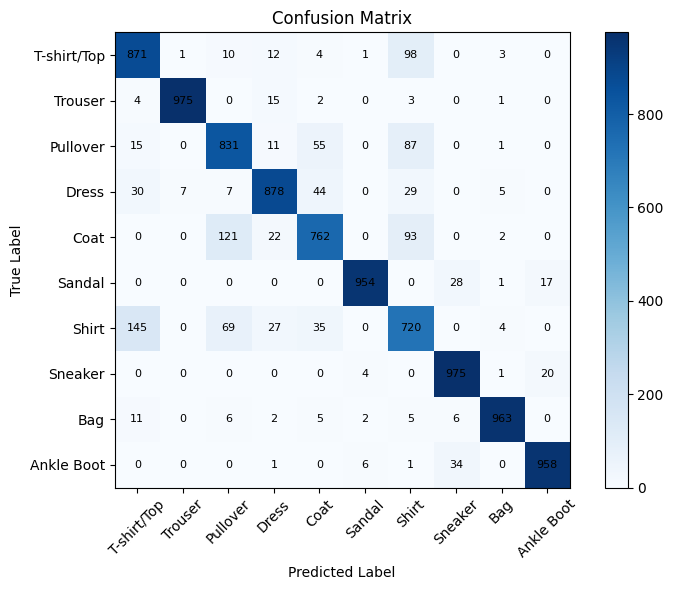

In [32]:
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j],
                 ha="center",
                 va="center",
                 fontsize=8)

plt.tight_layout()
plt.show()

### Hyperparameter Optimization

In [1]:
# Install compatible SciKeras and Scikit-learn
!pip uninstall -y scikit-learn scikeras
!pip install -q "scikit-learn==1.5.2" "scikeras==0.13.0"

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 86.5 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [2]:
import sklearn, scikeras
print("scikit-learn:", sklearn.__version__)
print("scikeras:", scikeras.__version__)

scikit-learn: 1.5.2
scikeras: 0.13.0


In [39]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [40]:
# Reload integer labels (because earlier we converted them into one-hot)

(_, y_train_int), (_, y_test_int) = keras.datasets.fashion_mnist.load_data()

In [41]:
# Build configurable model

def create_model(
    hidden_layers=2,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer="adam",
    activation="relu",
    dropout_rate=0.0,
):

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(784,)))

    for i in range(hidden_layers):
        model.add(
            keras.layers.Dense(
                hidden_neurons,
                activation=activation
            )
        )

        if dropout_rate > 0:
            model.add(
                keras.layers.Dropout(dropout_rate)
            )

    model.add(
        keras.layers.Dense(
            10,
            activation="softmax"
        )
    )

    # Optimizer Selection

    if optimizer == "adam":
        opt = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer == "sgd":
        opt = keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    else:
        opt = keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [42]:
# Wrap model using SciKeras

classifier = KerasClassifier(
    model=create_model,
)

In [43]:
# Hyperparameter Search Space

param_grid = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__optimizer": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30]
}

In [44]:
# Randomized Search
random_search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_grid,
    n_iter=30,          
    cv=3,               # 3-fold instead of 5, to cut compute further
    scoring="accuracy",
    verbose=2,
    n_jobs=-1,
    random_state=42      
)

In [45]:
# Start Search

print("Starting Hyperparameter Search...\n")

random_search.fit(
    X_train.astype(np.float32),
    y_train_int.astype(np.float32)
)

print("\nHyperparameter Search Completed!")


Starting Hyperparameter Search...

Fitting 3 folds for each of 30 candidates, totalling 90 fits


I0000 00:00:1784727963.972296     722 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12816 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784727963.978581     722 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13612 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784727964.066580     723 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12814 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784727964.068916     723 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13348 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784727964.075063     724 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:

Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/10


I0000 00:00:1784727970.565169     784 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1784727970.609665     800 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1784727970.643667     809 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


   1/2500 ━━━━━━━━━━━━━━━━━━━━ 3:31:39 5s/step - accuracy: 0.0625 - loss: 2.5389090

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6422 - loss: 1.0903
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1658 - loss: 2.3103
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3211 - loss: 1.9241
Epoch 2/10
465/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6642 - loss: 1.0191[CV] END batch_size=32, epochs=10, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=2, model__hidden_neurons=32, model__learning_rate=0.1, model__optimizer=adam; total time= 1.2min
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6747 - loss: 0.9853
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6883 - loss: 1.0086
Epoch 20/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5643 - loss: 1.3276
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6936 - loss: 0.9192
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6309 - loss: 1.1158
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5

I0000 00:00:1784730678.562562   27118 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11220 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784730678.565533   27118 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13348 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


1917/2500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1031 - loss: 3.7672Epoch 1/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.1019 - loss: 3.6923
Epoch 2/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0997 - loss: 3.6727
Epoch 4/30
  24/2500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.1021 - loss: 4.9197: 3.6486

I0000 00:00:1784730685.421400   27182 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0995 - loss: 3.6381
Epoch 3/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.1054 - loss: 3.6285
Epoch 2/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0996 - loss: 3.6415
 521/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0935 - loss: 3.6411Epoch 5/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0993 - loss: 3.6504
Epoch 4/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0988 - loss: 3.6605
Epoch 3/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0982 - loss: 3.5999
Epoch 6/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.1032 - loss: 3.6118
Epoch 4/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.0987 - loss: 3.5893
Epoch 7/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.0978 - loss: 3.6015
Epoch 5/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.1013 - loss: 3.6313
Epoch 5/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 10s 4

In [46]:
# Best Parameters

print("\nBest Hyperparameters:\n")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

# Best Model
best_model = random_search.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)


Best Hyperparameters:

{'model__optimizer': 'adam', 'model__learning_rate': 0.001, 'model__hidden_neurons': 256, 'model__hidden_layers': 2, 'model__dropout_rate': 0.0, 'model__activation': 'sigmoid', 'epochs': 30, 'batch_size': 32}

Best Cross Validation Accuracy:
0.8936833333333333
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [47]:
# Evaluation

accuracy = accuracy_score(y_test_int, y_pred)
precision = precision_score(y_test_int, y_pred, average="weighted")
recall = recall_score(y_test_int, y_pred, average="weighted")
f1 = f1_score(y_test_int, y_pred, average="weighted")
cm = confusion_matrix(y_test_int, y_pred)
report = classification_report(y_test_int, y_pred)

In [48]:
# Print Results

print("\n===============================")
print("Optimized Model Performance")
print("===============================\n")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nConfusion Matrix\n")
print(cm)
print("\nClassification Report\n")
print(report)


Optimized Model Performance

Accuracy : 0.8949
Precision: 0.8956
Recall   : 0.8949
F1 Score : 0.8931

Confusion Matrix

[[868   1  24  24   6   1  65   0  11   0]
 [  2 982   2   9   3   0   1   0   1   0]
 [ 15   2 884   9  60   0  26   0   4   0]
 [ 17   9  17 898  42   0  12   0   5   0]
 [  0   1 114  21 826   0  33   0   5   0]
 [  0   0   0   1   0 960   0  18   2  19]
 [148   1 120  29  80   0 607   0  15   0]
 [  0   0   0   0   0   7   0 966   0  27]
 [  4   0   3   3   2   1   1   3 983   0]
 [  1   0   0   0   0   4   0  20   0 975]]

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1000
           1       0.99      0.98      0.98      1000
           2       0.76      0.88      0.82      1000
           3       0.90      0.90      0.90      1000
           4       0.81      0.83      0.82      1000
           5       0.99      0.96      0.97      1000
           6       0.81      0.61      0.70  

In [49]:
# Compare with Baseline

baseline_loss, baseline_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\n===============================")
print("Comparison")
print("===============================\n")

print(f"Baseline Accuracy  : {baseline_accuracy:.4f}")
print(f"Optimized Accuracy : {accuracy:.4f}")


Comparison

Baseline Accuracy  : 0.8887
Optimized Accuracy : 0.8949


#### Hyperparameter Search Result

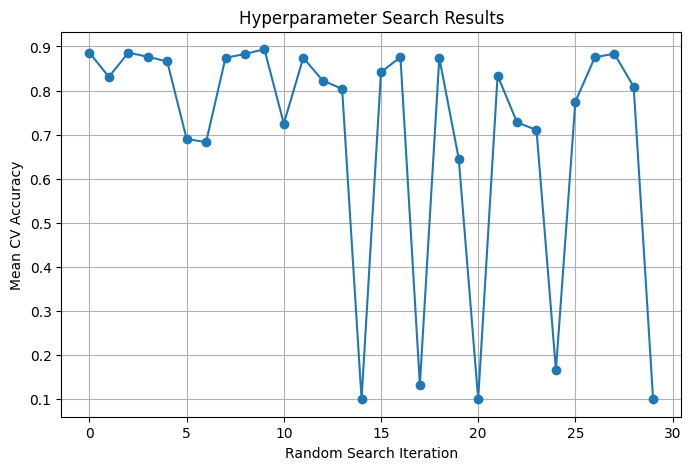

In [50]:
results = random_search.cv_results_
plt.figure(figsize=(8,5))
plt.plot(results["mean_test_score"], marker="o")
plt.xlabel("Random Search Iteration")
plt.ylabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results")
plt.grid(True)
plt.show()

#### Baseline vs Optimized Accuracy

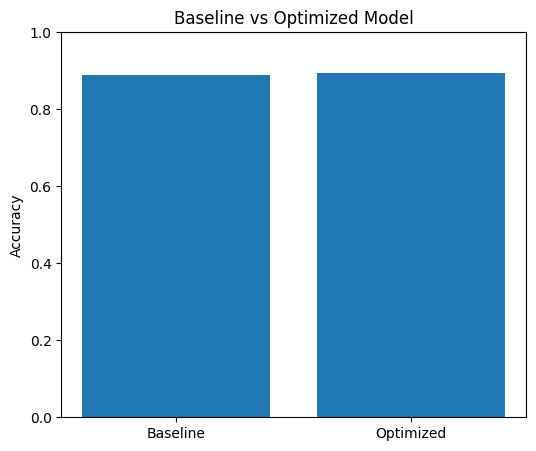

In [51]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Baseline","Optimized"],
    [baseline_accuracy, accuracy]
)

plt.ylabel("Accuracy")
plt.title("Baseline vs Optimized Model")
plt.ylim(0,1)
plt.show()